In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

from genome_mining.descarga import descargar_genoma, obtener_rutas_archivos

In [3]:
ruta = descargar_genoma("GCF_017499595.1", carpeta_destino="../datos")
print(f"Genoma descargado en: {ruta}")

El genoma GCF_017499595.1 ya fue descargado previamente, se reutiliza.
Genoma descargado en: ../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1


In [4]:
archivos = obtener_rutas_archivos(ruta, "GCF_017499595.1")
archivos

{'fasta': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/GCF_017499595.1_MGC_Penvy_1_genomic.fna'),
 'gff': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/genomic.gff'),
 'proteinas': PosixPath('../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa')}

In [5]:
from genome_mining.blast_utils import descargar_secuencias_referencia, construir_base_blast, correr_blast

genes_interes = {
    "PsiD": "P0DPA6",
    "PsiH": "P0DPA7",
    "PsiK": "P0DPA8",
    "PsiM": "P0DPA9",
}

ruta_referencias = descargar_secuencias_referencia(genes_interes, "../resultados/psilocybe_cubensis/referencias.fasta")

PsiD (P0DPA6) descargado correctamente
PsiH (P0DPA7) descargado correctamente
PsiK (P0DPA8) descargado correctamente
PsiM (P0DPA9) descargado correctamente


In [6]:
ruta_db = construir_base_blast(archivos["proteinas"], "../resultados/psilocybe_cubensis/blast_db/proteinas")



Building a new DB, current time: 07/08/2026 18:35:04
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
New DB title:  ../datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 13330 sequences in 0.137788 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


In [7]:
resultados = correr_blast(ruta_referencias, ruta_db, "../resultados/psilocybe_cubensis/blast_resultados.tsv")
resultados[resultados["identidad"] == 100.0]

Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


,query,hit,identidad,longitud,evalue,bitscore,descripcion
0,sp|P0DPA6|PSID_PSICU,XP_047744498.1,100.0,439,0.0,917.0,XP_047744498.1 L-tryptophan decarboxylase [Psi...
8,sp|P0DPA7|PSIH_PSICU,XP_047744495.1,100.0,438,0.0,908.0,XP_047744495.1 Tryptamine 4-monooxygenase [Psi...
101,sp|P0DPA8|PSIK_PSICU,XP_047744494.1,100.0,362,0.0,759.0,XP_047744494.1 Major facilitator-type transpor...
103,sp|P0DPA9|PSIM_PSICU,XP_047744497.1,100.0,309,0.0,642.0,XP_047744497.1 Psilocybin synthase [Psilocybe ...


In [8]:
from genome_mining.visualizacion import extraer_coordenadas, graficar_cluster

# Mapeamos nombre de gen -> accession de proteína (usando los resultados de 100% identidad)
accesiones_confirmadas = {
    "PsiD": "XP_047744498.1",
    "PsiH": "XP_047744495.1",
    "PsiK": "XP_047744494.1",
    "PsiM": "XP_047744497.1",
}

coordenadas = extraer_coordenadas(archivos["gff"], accesiones_confirmadas)
coordenadas

{'PsiD': {'inicio': 1676182, 'fin': 1677607, 'hebra': '-'},
 'PsiH': {'inicio': 1667511, 'fin': 1669282, 'hebra': '+'},
 'PsiK': {'inicio': 1663425, 'fin': 1667194, 'hebra': '+'},
 'PsiM': {'inicio': 1673493, 'fin': 1675081, 'hebra': '-'}}

Gráfico guardado en: ../resultados/psilocybe_cubensis/cluster.png


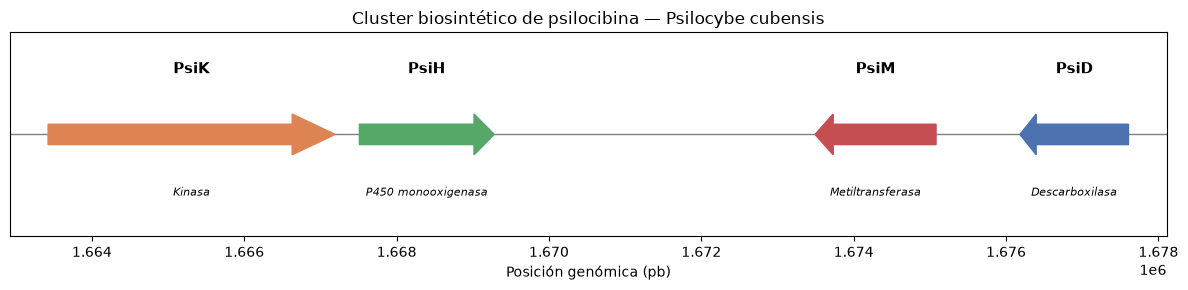

In [9]:
productos = {"PsiD": "Descarboxilasa", "PsiH": "P450 monooxigenasa", "PsiK": "Kinasa", "PsiM": "Metiltransferasa"}

graficar_cluster(
    coordenadas,
    titulo="Cluster biosintético de psilocibina — Psilocybe cubensis",
    productos=productos,
    ruta_salida="../resultados/psilocybe_cubensis/cluster.png"
)

--- Analizando Psilocybe cubensis ---
Descargando genoma...
El genoma GCF_017499595.1 ya fue descargado previamente, se reutiliza.
Descargando secuencias de referencia...
PsiD (P0DPA6) descargado correctamente
PsiH (P0DPA7) descargado correctamente
PsiK (P0DPA8) descargado correctamente
PsiM (P0DPA9) descargado correctamente
Construyendo base de datos BLAST...


Building a new DB, current time: 07/08/2026 18:35:12
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
New DB title:  datos/GCF_017499595.1/ncbi_dataset/data/GCF_017499595.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/resultados/psilocybe_cubensis/blast_db/proteinas
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 13330 sequences in 0.131932 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Corriendo BLAST...


Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Se encontraron 4 genes con al menos un match
                    query             hit  identidad
0    sp|P0DPA6|PSID_PSICU  XP_047744498.1      100.0
8    sp|P0DPA7|PSIH_PSICU  XP_047744495.1      100.0
103  sp|P0DPA9|PSIM_PSICU  XP_047744497.1      100.0
101  sp|P0DPA8|PSIK_PSICU  XP_047744494.1      100.0
Extrayendo coordenadas del GFF3...
Generando visualización...
Gráfico guardado en: ../resultados/psilocybe_cubensis/cluster.png


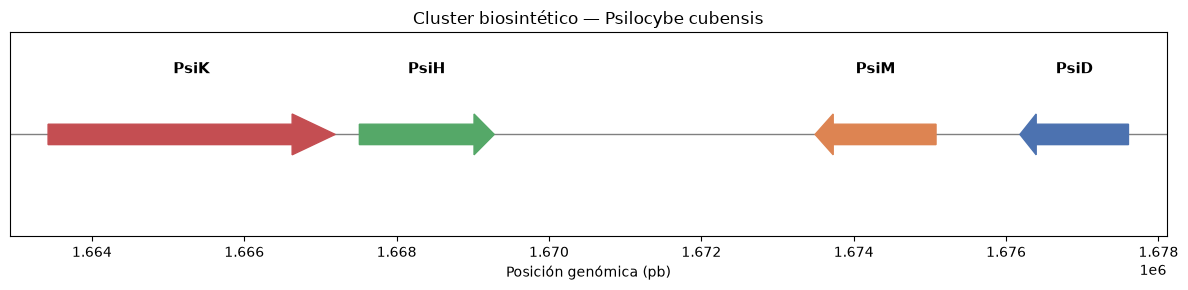

In [10]:
from genome_mining.pipeline import analizar_especie

coordenadas = analizar_especie("psilocybe_cubensis", config_path="../config/especies.yaml", carpeta_resultados="../resultados")

In [11]:
import sys
sys.path.append("..")

In [12]:
import sys
sys.path.append("..")

In [13]:
from genome_mining.pipeline import agregar_especie

In [14]:
agregar_especie(
    nombre_cientifico="Cordyceps militaris",
    genes_interes={
        "Cns1": "G3JF08",
        "Cns2": "G3JF09",
        "Cns3": "G3JF10",
        "Cns4": "G3JF11",
    },
    config_path="../config/especies.yaml"
)

Accession seleccionado automáticamente: GCA_008080495.1 (N50: 5,778,387 bp)
Especie 'cordyceps_militaris' agregada/actualizada en ../config/especies.yaml


'cordyceps_militaris'

--- Analizando Cordyceps militaris ---
Descargando genoma...
El genoma GCA_008080495.1 ya fue descargado previamente, se reutiliza.
Descargando secuencias de referencia...
Cns1 (G3JF08) descargado correctamente
Cns2 (G3JF09) descargado correctamente
Cns3 (G3JF10) descargado correctamente
Cns4 (G3JF11) descargado correctamente
Construyendo base de datos BLAST...


Building a new DB, current time: 07/08/2026 18:35:21
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/resultados/cordyceps_militaris/blast_db/proteinas
New DB title:  datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/resultados/cordyceps_militaris/blast_db/proteinas
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 9287 sequences in 0.0948482 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Corriendo BLAST...


Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Se encontraron 4 genes con al menos un match
                  query         hit  identidad
2  sp|G3JF10|CNS3_CORMM  ATY65134.1     99.885
1  sp|G3JF09|CNS2_CORMM  ATY65129.1     99.710
0  sp|G3JF08|CNS1_CORMM  ATY65128.1     98.990
3  sp|G3JF11|CNS4_CORMM  ATY65135.1     96.976
Extrayendo coordenadas del GFF3...
Generando visualización...
Gráfico guardado en: ../resultados/cordyceps_militaris/cluster.png


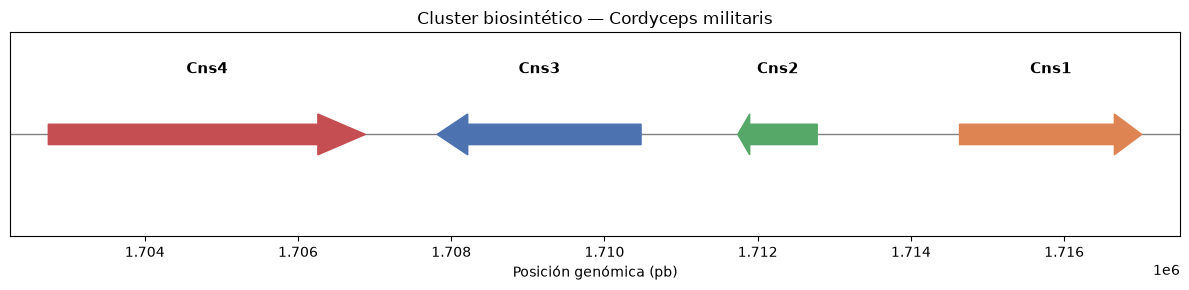

In [15]:
coordenadas = analizar_especie(
    "cordyceps_militaris",
    config_path="../config/especies.yaml",
    carpeta_resultados="../resultados"
)

In [16]:
import sys
sys.path.append("..")
from genome_mining.descarga import descargar_genoma, obtener_rutas_archivos

# Reemplaza con el accession que identifiques como el de mejor calidad
ruta = descargar_genoma("GCA_006506795.2", carpeta_destino="../datos")
archivos = obtener_rutas_archivos(ruta, "GCA_006506795.2")
archivos

Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/ncbi_dataset.zip    2.12kB 17.1MB/s
Downloading: ../datos/GCA_006506795.2/

Archive:  ../datos/GCA_006506795.2/ncbi_dataset.zip
  inflating: ../datos/GCA_006506795.2/README.md  
  inflating: ../datos/GCA_006506795.2/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ../datos/GCA_006506795.2/ncbi_dataset/data/GCA_006506795.2/GCA_006506795.2_HeCS-4_2.0_genomic.fna  
  inflating: ../datos/GCA_006506795.2/ncbi_dataset/data/dataset_catalog.json  
  inflating: ../datos/GCA_006506795.2/md5sum.txt  


{'fasta': PosixPath('../datos/GCA_006506795.2/ncbi_dataset/data/GCA_006506795.2/GCA_006506795.2_HeCS-4_2.0_genomic.fna'),
 'gff': None,
 'proteinas': None}

In [17]:
from genome_mining.descarga import descargar_genoma, obtener_rutas_archivos

ruta_yarrowia = descargar_genoma("GCF_000002525.2", carpeta_destino="../datos")
archivos_yarrowia = obtener_rutas_archivos(ruta_yarrowia, "GCF_000002525.2")
archivos_yarrowia

Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.84kB 12.5MB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.96kB 29.1kB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.96kB 29.1kB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.96kB 29.1kB/s
Downloading: ../datos/GCF_000002525.2/ncbi_dataset.zip    2.96kB 29.1kB/s
Downloading: ../datos/GCF_000002525.2/

Archive:  ../datos/GCF_000002525.2/ncbi_dataset.zip
  inflating: ../datos/GCF_000002525.2/README.md  
  inflating: ../datos/GCF_000002525.2/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/GCF_000002525.2_ASM252v1_genomic.fna  
  inflating: ../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/genomic.gff  
  inflating: ../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/protein.faa  
  inflating: ../datos/GCF_000002525.2/ncbi_dataset/data/dataset_catalog.json  
  inflating: ../datos/GCF_000002525.2/md5sum.txt  


{'fasta': PosixPath('../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/GCF_000002525.2_ASM252v1_genomic.fna'),
 'gff': PosixPath('../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/genomic.gff'),
 'proteinas': PosixPath('../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/protein.faa')}

In [18]:
ruta_pichia = descargar_genoma("GCA_001746955.1", carpeta_destino="../datos")
archivos_pichia = obtener_rutas_archivos(ruta_pichia, "GCA_001746955.1")
archivos_pichia

Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    2.25kB 7.63MB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    2.25kB 7.63MB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    2.25kB 7.63MB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/ncbi_dataset.zip    3.39kB 78.7kB/s
Downloading: ../datos/GCA_001746955.1/

Archive:  ../datos/GCA_001746955.1/ncbi_dataset.zip
  inflating: ../datos/GCA_001746955.1/README.md  
  inflating: ../datos/GCA_001746955.1/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/GCA_001746955.1_ASM174695v1_genomic.fna  
  inflating: ../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/genomic.gff  
  inflating: ../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/protein.faa  
  inflating: ../datos/GCA_001746955.1/ncbi_dataset/data/dataset_catalog.json  
  inflating: ../datos/GCA_001746955.1/md5sum.txt  


{'fasta': PosixPath('../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/GCA_001746955.1_ASM174695v1_genomic.fna'),
 'gff': PosixPath('../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/genomic.gff'),
 'proteinas': PosixPath('../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/protein.faa')}

In [19]:
def limpiar_gff_para_antismash(ruta_gff_original, ruta_gff_limpio):
    """
    Limpia un GFF3 para que sea compatible con antiSMASH:
    - Elimina features con tipos no estándar (ej. pseudogenic_tRNA)
    - Elimina líneas CDS duplicadas con coordenadas idénticas
    """
    tipos_problematicos = {"pseudogenic_tRNA"}
    cds_vistos = set()

    with open(ruta_gff_original) as f_in, open(ruta_gff_limpio, "w") as f_out:
        for linea in f_in:
            if linea.startswith("#"):
                f_out.write(linea)
                continue

            campos = linea.strip().split("\t")
            if len(campos) < 9:
                f_out.write(linea)
                continue

            tipo = campos[2]

            # Filtrar tipos problemáticos
            if tipo in tipos_problematicos:
                continue

            # Filtrar CDS duplicados por coordenadas exactas
            if tipo == "CDS":
                clave = (campos[0], campos[3], campos[4], campos[6])  # contig, inicio, fin, hebra
                if clave in cds_vistos:
                    continue
                cds_vistos.add(clave)

            f_out.write(linea)

    print(f"GFF limpio guardado en: {ruta_gff_limpio}")

In [20]:
limpiar_gff_para_antismash(
    "../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/genomic.gff",
    "../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/genomic_limpio.gff"
)

limpiar_gff_para_antismash(
    "../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/genomic.gff",
    "../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/genomic_limpio.gff"
)

GFF limpio guardado en: ../datos/GCF_000002525.2/ncbi_dataset/data/GCF_000002525.2/genomic_limpio.gff
GFF limpio guardado en: ../datos/GCA_001746955.1/ncbi_dataset/data/GCA_001746955.1/genomic_limpio.gff


In [21]:
ruta_aspergillus = descargar_genoma("GCF_000184455.2", carpeta_destino="../datos")
archivos_aspergillus = obtener_rutas_archivos(ruta_aspergillus, "GCF_000184455.2")
archivos_aspergillus

Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    2.49kB 756kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    3.93kB 346kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    10.1kB 114kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    10.1kB 114kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    10.1kB 114kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    32.8kB 254kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.zip    32.8kB 254kB/s
Downloading: ../datos/GCF_000184455.2/ncbi_dataset.

Archive:  ../datos/GCF_000184455.2/ncbi_dataset.zip
  inflating: ../datos/GCF_000184455.2/README.md  
  inflating: ../datos/GCF_000184455.2/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/GCF_000184455.2_ASM18445v3_genomic.fna  
  inflating: ../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/genomic.gff  
  inflating: ../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/protein.faa  
  inflating: ../datos/GCF_000184455.2/ncbi_dataset/data/dataset_catalog.json  
  inflating: ../datos/GCF_000184455.2/md5sum.txt  


{'fasta': PosixPath('../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/GCF_000184455.2_ASM18445v3_genomic.fna'),
 'gff': PosixPath('../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/genomic.gff'),
 'proteinas': PosixPath('../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/protein.faa')}

In [22]:
limpiar_gff_para_antismash(
    archivos_aspergillus["gff"],
    archivos_aspergillus["gff"].parent / "genomic_limpio.gff"
)

GFF limpio guardado en: ../datos/GCF_000184455.2/ncbi_dataset/data/GCF_000184455.2/genomic_limpio.gff


In [23]:
import yaml

with open("../config/especies.yaml") as f:
    config = yaml.safe_load(f)

accession_cordyceps = config["especies"]["cordyceps_militaris"]["accession"]
print(f"Accession: {accession_cordyceps}")

ruta_cordyceps = descargar_genoma(accession_cordyceps, carpeta_destino="../datos")
archivos_cordyceps = obtener_rutas_archivos(ruta_cordyceps, accession_cordyceps)
archivos_cordyceps

Accession: GCA_008080495.1


Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB 22MB/s
Downloading: ../datos/GCA_008080495.1/ncbi_dataset.zip    2.16kB

Archive:  ../datos/GCA_008080495.1/ncbi_dataset.zip
  inflating: ../datos/GCA_008080495.1/README.md  
  inflating: ../datos/GCA_008080495.1/ncbi_dataset/data/assembly_data_report.jsonl  
  inflating: ../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/GCA_008080495.1_ASM808049v1_genomic.fna  
  inflating: ../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/genomic.gff  
  inflating: ../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/protein.faa  
  inflating: ../datos/GCA_008080495.1/ncbi_dataset/data/dataset_catalog.json  
  inflating: ../datos/GCA_008080495.1/md5sum.txt  


{'fasta': PosixPath('../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/GCA_008080495.1_ASM808049v1_genomic.fna'),
 'gff': PosixPath('../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/genomic.gff'),
 'proteinas': PosixPath('../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/protein.faa')}

In [24]:
limpiar_gff_para_antismash(
    archivos_cordyceps["gff"],
    archivos_cordyceps["gff"].parent / "genomic_limpio.gff"
)

GFF limpio guardado en: ../datos/GCA_008080495.1/ncbi_dataset/data/GCA_008080495.1/genomic_limpio.gff


In [25]:
import json
import pandas as pd
from pathlib import Path

def resumir_resultados_antismash(carpeta_resultados="../resultados"):
    """
    Recorre todas las carpetas de resultados y extrae un resumen de
    regiones/clusters encontrados por antiSMASH para cada especie.
    """
    filas = []
    carpeta_resultados = Path(carpeta_resultados)

    for carpeta_especie in carpeta_resultados.iterdir():
        carpeta_antismash = carpeta_especie / "antismash"
        if not carpeta_antismash.exists():
            continue

        archivos_json = list(carpeta_antismash.glob("*.json"))
        if not archivos_json:
            continue

        with open(archivos_json[0]) as f:
            data = json.load(f)

        nombre_especie = carpeta_especie.name

        for record in data.get("records", []):
            for region in record.get("areas", record.get("regions", [])):
                # La estructura exacta puede variar según versión de antiSMASH
                pass

        # Antisash 7/8 guarda las regiones dentro de cada 'record' -> 'areas'
        for record in data.get("records", []):
            regiones = record.get("areas") or record.get("regions") or []
            for region in regiones:
                filas.append({
                    "especie": nombre_especie,
                    "contig": record.get("id", ""),
                    "tipo": ", ".join(region.get("products", region.get("type", ["desconocido"]))) if isinstance(region.get("products", region.get("type")), list) else region.get("products", region.get("type", "desconocido")),
                    "inicio": region.get("start"),
                    "fin": region.get("end"),
                })

    return pd.DataFrame(filas)

tabla_resumen = resumir_resultados_antismash("../resultados")
tabla_resumen

,especie,contig,tipo,inicio,fin
0,cordyceps_militaris,CP023328.1,T1PKS,1604823,1672339
1,cordyceps_militaris,CP023327.1,T1PKS,0,57887
2,cordyceps_militaris,CP023327.1,terpene-precursor,2321009,2352398
3,cordyceps_militaris,CP023327.1,T1PKS,2407367,2474117
4,cordyceps_militaris,CP023326.1,"NRPS, T1PKS",12530,85130
...,...,...,...,...,...
119,aspergillus_oryzae,NC_036442.1,"NRPS-like, T1PKS",2213649,2333362
120,aspergillus_oryzae,NC_036442.1,NRPS-like,2396468,2459772
121,aspergillus_oryzae,NC_036442.1,terpene,2845397,2877007
122,aspergillus_oryzae,NC_036442.1,T1PKS,3071937,3139728


In [26]:
resumen_conteo = (
    tabla_resumen
    .groupby("especie")
    .agg(
        total_clusters=("tipo", "count"),
        tipos_unicos=("tipo", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
    .sort_values("total_clusters", ascending=False)
)

resumen_conteo

,especie,total_clusters,tipos_unicos
0,aspergillus_oryzae,80,"NI-siderophore, terpene, NRPS, NRPS, NRPS-like..."
1,cordyceps_militaris,37,"NAPAA, NRP-metallophore, NRPS, NRPS, NRPS, T1P..."
3,yarrowia_lipolytica,4,"terpene, terpene-precursor"
2,komagataella_phaffii,3,"terpene, terpene-precursor"


In [27]:
def categorizar_tipo(tipo):
    tipo = tipo.lower()
    if "pks" in tipo:
        return "PKS (policétidos)"
    elif "nrps" in tipo:
        return "NRPS (péptidos no ribosomales)"
    elif "terpene" in tipo:
        return "Terpenos"
    else:
        return "Otro"

tabla_resumen["categoria"] = tabla_resumen["tipo"].apply(categorizar_tipo)

resumen_categorias = (
    tabla_resumen
    .groupby(["especie", "categoria"])
    .size()
    .reset_index(name="cantidad")
)

resumen_categorias

,especie,categoria,cantidad
0,aspergillus_oryzae,NRPS (péptidos no ribosomales),24
1,aspergillus_oryzae,Otro,7
2,aspergillus_oryzae,PKS (policétidos),29
3,aspergillus_oryzae,Terpenos,20
4,cordyceps_militaris,NRPS (péptidos no ribosomales),11
5,cordyceps_militaris,Otro,5
6,cordyceps_militaris,PKS (policétidos),13
7,cordyceps_militaris,Terpenos,8
8,komagataella_phaffii,Terpenos,3
9,yarrowia_lipolytica,Terpenos,4


In [28]:
tabla_pivote = resumen_categorias.pivot(index="especie", columns="categoria", values="cantidad").fillna(0).astype(int)
tabla_pivote["total"] = tabla_pivote.sum(axis=1)
tabla_pivote = tabla_pivote.sort_values("total", ascending=False)
tabla_pivote

categoria,NRPS (péptidos no ribosomales),Otro,PKS (policétidos),Terpenos,total
especie,,,,,
aspergillus_oryzae,24,7,29,20,80
cordyceps_militaris,11,5,13,8,37
yarrowia_lipolytica,0,0,0,4,4
komagataella_phaffii,0,0,0,3,3


In [29]:
def graficar_comparacion_especies(tabla_pivote, ruta_salida=None):
    """
    Genera un gráfico de barras apiladas comparando la cantidad de
    clusters biosintéticos por categoría, entre especies.
    """
    columnas_categorias = [c for c in tabla_pivote.columns if c != "total"]
    colores = ["#4C72B0", "#DD8452", "#55A868", "#8172B2"]

    fig, ax = plt.subplots(figsize=(10, 5))
    tabla_pivote[columnas_categorias].plot(
        kind="barh", stacked=True, ax=ax, color=colores[:len(columnas_categorias)]
    )

    ax.set_xlabel("Número de clusters detectados")
    ax.set_ylabel("")
    ax.set_title("Clusters biosintéticos detectados por antiSMASH, por especie")
    ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if ruta_salida:
        plt.savefig(ruta_salida, dpi=150, bbox_inches="tight")
        print(f"Gráfico guardado en: {ruta_salida}")

    plt.show()

Gráfico guardado en: ../resultados/comparacion_especies.png


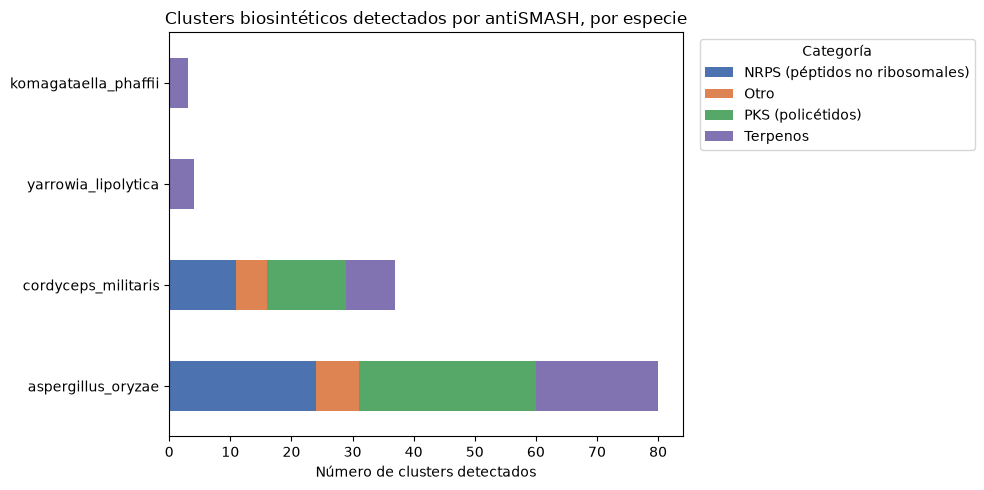

In [30]:
from genome_mining.visualizacion import graficar_comparacion_especies

graficar_comparacion_especies(tabla_pivote, ruta_salida="../resultados/comparacion_especies.png")